In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def parse_mums_file(filepath, label):
    """
    Parses a .mums file.
    - Length: 1st column
    - Present_Count: number of non-empty entries in 2nd column
    - Location_Consistency: 1 if all positions are identical, else 0
    """
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            length = int(parts[0])
            presence_list = [x.strip() for x in parts[1].split(',') if x.strip() != '']
            present_count = len(presence_list)
            is_consistent = 1 if len(set(presence_list)) == 1 else 0
            data.append({
                'Length': length,
                'Present_Count': present_count,
                'Location_Consistency': is_consistent,
                'loc': presence_list[0] if is_consistent else None,
                'Dataset': label
            })
    return pd.DataFrame(data)

def calculate_n50(lengths):
    if len(lengths) == 0: return 0
    sorted_lengths = np.sort(lengths)[::-1]
    cumulative_sum = np.cumsum(sorted_lengths)
    return sorted_lengths[np.where(cumulative_sum >= sorted_lengths.sum() / 2)[0][0]]

In [5]:
data_root = "/dodo/rdd4/mft-data/data"

In [6]:
data_root = "/dodo/rdd4/mft-data/data"
# data_root = "/dodo/rdd4/mft-data/data_longer_sequences"

all_data = []
missing = []

for combo in sorted(os.listdir(data_root)):
    combo_path = os.path.join(data_root, combo)
    if not os.path.isdir(combo_path):
        continue
    csv_path = os.path.join(combo_path, 'parsed.csv')
    if os.path.exists(csv_path):
        all_data.append(pd.read_csv(csv_path))
    else:
        missing.append(combo)

if missing:
    print(f"Warning: {len(missing)} folders have no parsed.csv — run preprocess_mums.py first.")
    print("  Missing:", missing[:10], "..." if len(missing) > 10 else "")

df_master = pd.concat(all_data, ignore_index=True)

# Replicate column present for replicated data; default to 1 for legacy folders.
if 'Replicate' not in df_master.columns:
    df_master['Replicate'] = 1

print(df_master.shape)
df_master

KeyboardInterrupt: 

In [7]:
# Filter to all-present MUMs only (same logic as fig2)
df_filtered = df_master[
    (df_master['Length'] <= 10000) &
    (df_master['Length'] >= 20) &
    (df_master['Present_Count'] == df_master['n']) &
    (df_master['Location_Consistency'] == 1)
]

ns         = sorted(df_master['n'].unique().astype(int))
alphas     = sorted(df_master['Alpha'].unique())
replicates = sorted(df_master['Replicate'].unique().astype(int))
datasets   = ['MFT (w=11)', 'MFT (w=8)', 'MFT (w=5)', 'Nucleotide']

full_index = pd.MultiIndex.from_product(
    [ns, alphas, replicates, datasets],
    names=['n', 'Alpha', 'Replicate', 'Dataset']
)

summary_df = (
    df_filtered
    .groupby(['n', 'Alpha', 'Replicate', 'Dataset'])
    .apply(
        lambda x: pd.Series({
            'N50':                      calculate_n50(x['Length'].values),
            'Total_MUMs':               len(x),
            'Coverage':                 x['Length'].sum(),
            'Location_Consistent_MUMs': x['Location_Consistency'].sum(),
        }),
        include_groups=False,
    )
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(summary_df.shape)
summary_df

NameError: name 'df_master' is not defined

In [ ]:
summary_df.to_csv('summary_df.csv')

In [8]:
summary_df = pd.read_csv('summary_df.csv')
summary_df

,Unnamed: 0,n,Alpha,Replicate,Dataset,N50,Total_MUMs,Coverage,Location_Consistent_MUMs
0,0,2,0.0025,1,MFT (w=11),937,16,8938,16
1,1,2,0.0025,1,MFT (w=8),587,22,8920,22
2,2,2,0.0025,1,MFT (w=5),451,27,8885,27
3,3,2,0.0025,1,Nucleotide,376,32,8953,32
4,4,2,0.0025,2,MFT (w=11),2424,8,8683,8
...,...,...,...,...,...,...,...,...,...
7275,7275,500,0.0500,9,Nucleotide,0,0,0,0
7276,7276,500,0.0500,10,MFT (w=11),0,0,0,0
7277,7277,500,0.0500,10,MFT (w=8),0,0,0,0
7278,7278,500,0.0500,10,MFT (w=5),0,0,0,0


In [9]:
chain_all     = []
chain_missing = []

for combo in sorted(os.listdir(data_root)):
    combo_path = os.path.join(data_root, combo)
    if not os.path.isdir(combo_path):
        continue
    csv_path = os.path.join(combo_path, 'chained_coverage.csv')
    if os.path.exists(csv_path):
        chain_all.append(pd.read_csv(csv_path))
    else:
        chain_missing.append(combo)

if chain_missing:
    print(f"Warning: {len(chain_missing)} folders missing chained_coverage.csv — run chain_mums.py first.")

chain_df_master = pd.concat(chain_all, ignore_index=True)
print(chain_df_master.shape)
chain_df_master

(152880, 9)


,Dataset,Min_Length,D,Chained_Coverage,Num_Blocks,Mean_Block_Length,n,Alpha,Replicate
0,Nucleotide,10,0,2555,187,13.663102,100,0.0025,1
1,Nucleotide,10,50,4968,54,92.000000,100,0.0025,1
2,Nucleotide,10,100,7510,18,417.222222,100,0.0025,1
3,Nucleotide,10,150,8881,7,1268.714286,100,0.0025,1
4,Nucleotide,10,200,9546,3,3182.000000,100,0.0025,1
...,...,...,...,...,...,...,...,...,...
152875,MFT (w=11),30,100,0,0,0.000000,90,0.0500,9
152876,MFT (w=11),30,150,0,0,0.000000,90,0.0500,9
152877,MFT (w=11),30,200,0,0,0.000000,90,0.0500,9
152878,MFT (w=11),30,500,0,0,0.000000,90,0.0500,9


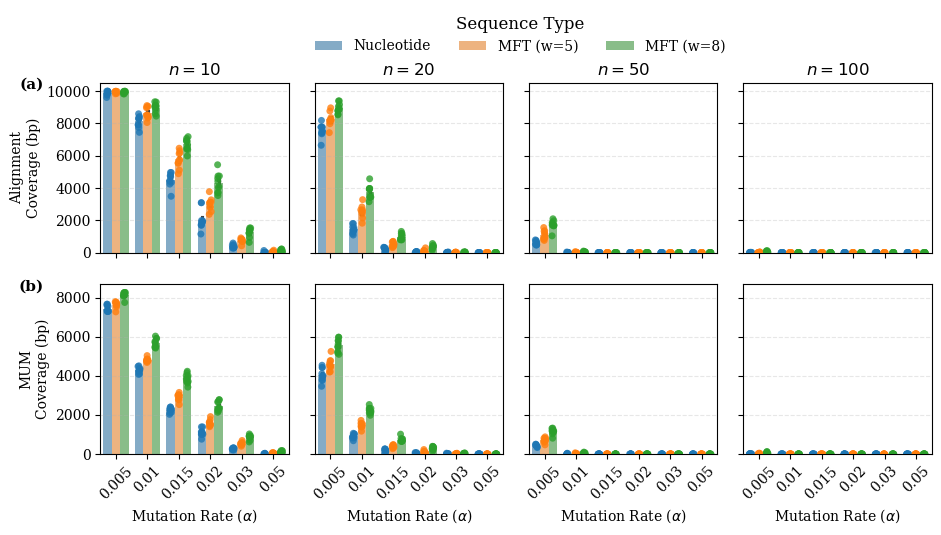

In [10]:
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)', 'MFT (w=11)']
hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)']
palette   = "tab10"

# ── Chaining parameters ── change to explore
D_value = 100
l_min   = 20

# ── Subset of n values to show as columns ── change as needed
n_show = [10, 20, 50, 100]

# ── Subset of alpha values to show on x-axis ── set to None to show all
alpha_x_show = [0.005, 0.01, 0.015, 0.02, 0.03, 0.05]

# Merge chained coverage at chosen D and l_min into summary_df
chain_at_params = chain_df_master[
    (chain_df_master['D'] == D_value) &
    (chain_df_master['Min_Length'] == l_min)
][['n', 'Alpha', 'Replicate', 'Dataset', 'Chained_Coverage']]

plot_df = summary_df.merge(chain_at_params, on=['n', 'Alpha', 'Replicate', 'Dataset'], how='left')

metrics = [
    ('Chained_Coverage', f'Alignment\nCoverage (bp)', None),
    ('Coverage',         'Multi-MUM\nCoverage (bp)',     None),
    ('N50',              'Multi-MUM\nN50 (bp)',              None),
]
metrics = [
    ('Chained_Coverage', f'Alignment\nCoverage (bp)', None),
    ('Coverage',         'MUM\nCoverage (bp)',     None),
]

n_cols = len(n_show)
fig, axes = plt.subplots(len(metrics), n_cols, figsize=(n_cols * 2.4, len(metrics)*2+1), sharey='row', sharex=True)

for col_idx, n_val in enumerate(n_show):
    df_sub = plot_df[plot_df['n'] == n_val]
    if alpha_x_show is not None:
        df_sub = df_sub[df_sub['Alpha'].isin(alpha_x_show)]

    for row_idx, (metric, ylabel, yscale) in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        sns.barplot(
            data=df_sub, x='Alpha', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
        )
        sns.stripplot(
            data=df_sub, x='Alpha', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, legend=False, alpha=0.8, dodge=True,
        )

        if row_idx == 0:
            ax.set_title(f'$n={n_val}$', fontweight='bold')

        ax.set_xlabel(r'Mutation Rate ($\alpha$)' if row_idx == len(metrics) - 1 else '')
        ax.set_ylabel(ylabel if col_idx == 0 else '')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if yscale:
            ax.set_yscale(yscale)
        if ax.get_legend():
            ax.get_legend().remove()

for row_idx in range(len(metrics)):
    label = chr(ord('a') + row_idx)
    axes[row_idx, 0].text(-0.30, 1.03, f'({label})', transform=axes[row_idx, 0].transAxes,
                          fontsize=11, fontweight='bold', va='top', ha='right')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.08),
           ncol=4, frameon=False, title="Sequence Type")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('simulated_data.png', dpi=300, bbox_inches='tight')
plt.savefig('simulated_data.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Filter to all-present MUMs only (same logic as fig2)
df_filtered = df_master[
    (df_master['Length'] <= 10000) &
    (df_master['Length'] >= 20) &
    (df_master['Present_Count'] == df_master['n'])
]

ns         = sorted(df_master['n'].unique().astype(int))
alphas     = sorted(df_master['Alpha'].unique())
replicates = sorted(df_master['Replicate'].unique().astype(int))
datasets   = ['MFT (w=11)', 'MFT (w=8)', 'MFT (w=5)', 'Nucleotide']

full_index = pd.MultiIndex.from_product(
    [ns, alphas, replicates, datasets],
    names=['n', 'Alpha', 'Replicate', 'Dataset']
)

summary_df = (
    df_filtered
    .groupby(['n', 'Alpha', 'Replicate', 'Dataset'])
    .apply(
        lambda x: pd.Series({
            'N50':                      calculate_n50(x['Length'].values),
            'Total_MUMs':               len(x),
            'Coverage':                 x['Length'].sum(),
            'Location_Consistent_MUMs': x['Location_Consistency'].sum(),
            'FP_Coverage':
                x.loc[x['Location_Consistency'] == 0, 'Length'].sum()
        }),
        include_groups=False,
    )
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(summary_df.shape)
summary_df

NameError: name 'df_master' is not defined

In [ ]:
summary_df.to_csv('summary_df_no_filter.csv')

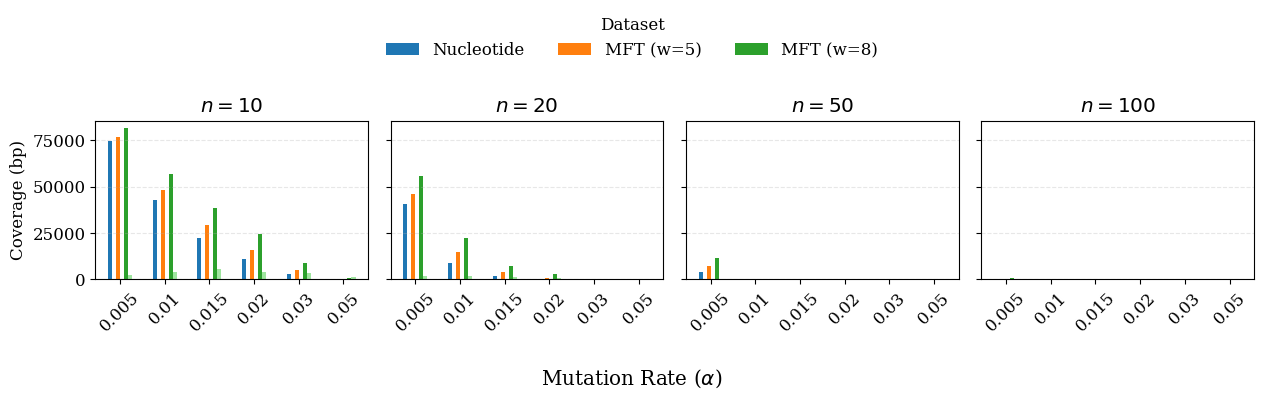

In [ ]:

from matplotlib.colors import to_rgb
import matplotlib.colors as mc
import colorsys

def lighten_color(color, amount=0.5):
    c = colorsys.rgb_to_hls(*to_rgb(color))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

# -----------------------------
# Aggregate
# -----------------------------
n_show     = [10, 20, 50, 100]
alpha_show = [0.005, 0.01, 0.015, 0.02, 0.03, 0.05]

plot_df = (
    summary_df
    .groupby(["n", "Alpha", "Dataset"])[['Coverage', 'FP_Coverage']]
    .sum()
    .reset_index()
)

plot_df = plot_df[
    plot_df['n'].isin(n_show) &
    plot_df['Alpha'].isin(alpha_show)
].copy()

plot_df['TP_Coverage'] = plot_df['Coverage'] - plot_df['FP_Coverage']

# -----------------------------
# Plot settings
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 12,
})

hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)']

base_palette = dict(zip(
    hue_order,
    sns.color_palette("tab10", n_colors=len(hue_order))
))
light_palette = {k: lighten_color(v, 0.4) for k, v in base_palette.items()}

fig, axes = plt.subplots(
    1, len(n_show),
    figsize=(len(n_show) * 3.2, 3.5),
    sharey=True
)

# 3 datasets × 2 bars (TP + FP) = 6 bars per alpha tick
# Bars indexed 0..5, centred around each tick:
#   TP bar for dataset d: position = (2*d - 2.5) * bar_width
#   FP bar for dataset d: position = (2*d - 1.5) * bar_width
bar_width = 0.09
x = np.arange(len(alpha_show))

for ax, n_val in zip(axes, n_show):
    df_sub = plot_df[plot_df['n'] == n_val]

    for d_idx, dataset in enumerate(hue_order):
        df_d = (
            df_sub[df_sub['Dataset'] == dataset]
            .set_index('Alpha')
            .reindex(alpha_show)
        )

        tp = df_d['TP_Coverage'].fillna(0).values
        fp = df_d['FP_Coverage'].fillna(0).values

        tp_offset = (2 * d_idx - 2.5) * bar_width
        fp_offset = (2 * d_idx - 1.5) * bar_width

        ax.bar(
            x + tp_offset, tp,
            width=bar_width,
            color=base_palette[dataset],
            label=dataset if ax is axes[0] else None,
        )
        ax.bar(
            x + fp_offset, fp,
            width=bar_width,
            color=light_palette[dataset],
        )

    ax.set_title(f'$n={n_val}$', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(alpha_show, rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Coverage (bp)')
fig.supxlabel(r'Mutation Rate ($\alpha$)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=4,
    frameon=False,
    title='Dataset'
)


plt.tight_layout()
plt.subplots_adjust(top=0.78)
plt.savefig('tp_fp_coverage.png', dpi=300, bbox_inches='tight')
plt.savefig('tp_fp_coverage.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
summary_df['FP_avg_length'] = summary_df['FP_Coverage'] / (summary_df['Total_MUMs'] - summary_df['Location_Consistent_MUMs'])

In [ ]:
summary_df

,n,Alpha,Replicate,Dataset,N50,Total_MUMs,Coverage,Location_Consistent_MUMs,FP_Coverage,FP_avg_length
0,2,0.0025,1,MFT (w=11),937,18,9017,16,79,39.5
1,2,0.0025,1,MFT (w=8),587,23,8954,22,34,34.0
2,2,0.0025,1,MFT (w=5),451,27,8885,27,0,NaN
3,2,0.0025,1,Nucleotide,376,32,8953,32,0,NaN
4,2,0.0025,2,MFT (w=11),2424,9,8722,8,39,39.0
...,...,...,...,...,...,...,...,...,...,...
7275,500,0.0500,9,Nucleotide,0,0,0,0,0,NaN
7276,500,0.0500,10,MFT (w=11),0,0,0,0,0,NaN
7277,500,0.0500,10,MFT (w=8),0,0,0,0,0,NaN
7278,500,0.0500,10,MFT (w=5),0,0,0,0,0,NaN


<Axes: >

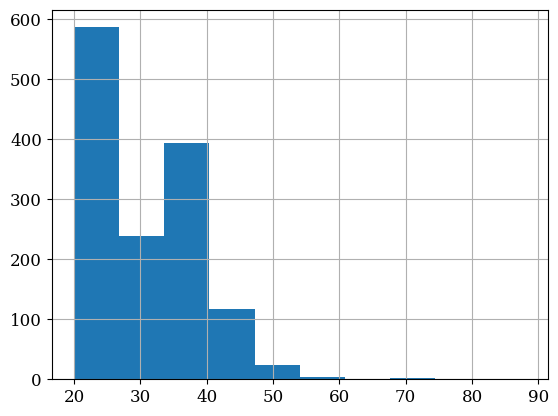

In [ ]:
summary_df['FP_avg_length'].hist()

In [ ]:
import re
hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)']

parsnp_root = "/dodo/rdd4/mft-data/data_parsnp"

dataset_name_map_parsnp = {
    "nucleotide": "Nucleotide",
    "mft_w5":     "MFT (w=5)",
    "mft_w8":     "MFT (w=8)",
}

folder_re_parsnp = re.compile(r"^(\d+)_([\d.]+)_rep(\d+)$")

parsnp_rows = []
for folder in sorted(os.listdir(parsnp_root)):
    m = folder_re_parsnp.match(folder)
    if not m:
        continue
    csv_path = os.path.join(parsnp_root, folder, "parsnp_summary_short.csv")
    if not os.path.exists(csv_path):
        continue
    parsnp_rows.append(pd.read_csv(csv_path))

parsnp_df = pd.concat(parsnp_rows, ignore_index=True)
parsnp_df["Dataset"] = parsnp_df["dataset"].map(dataset_name_map_parsnp)
# parsnp_df["SNP_precision"] = np.where(
#     (parsnp_df["tp"] + parsnp_df["fp"]) != 0,
#     parsnp_df["tp"] / (parsnp_df["tp"] + parsnp_df["fp"]),
#     1.0
# )
parsnp_df["SNP_precision"] = parsnp_df["tp"] / (parsnp_df["tp"] + parsnp_df["fp"])
parsnp_df['SNP_recall'] = parsnp_df['tp'] / (parsnp_df['tp'] + parsnp_df['fn'])
parsnp_df = parsnp_df[parsnp_df["Dataset"].isin(hue_order)].copy()
print(parsnp_df.shape)
parsnp_df


(5460, 17)


,dataset,n,alpha,rep,core_pre,core_length,snps_pre,snps_length,fp_lcbs,time_s,tp,fp,fn,truth_snps,Dataset,SNP_precision,SNP_recall
0,nucleotide,100,0.0025,1,14.32,13.37,0,259,4,4.00,278,0,2044,2322,Nucleotide,1.0,0.119724
1,mft_w5,100,0.0025,1,39.09,37.76,0,790,5,5.40,854,0,1468,2322,MFT (w=5),1.0,0.367786
2,mft_w8,100,0.0025,1,56.37,55.88,0,1153,2,6.93,1229,0,1093,2322,MFT (w=8),1.0,0.529285
4,nucleotide,100,0.0025,10,14.32,13.37,0,259,4,3.62,278,0,2044,2322,Nucleotide,1.0,0.119724
5,mft_w5,100,0.0025,10,39.09,37.76,0,790,5,5.31,854,0,1468,2322,MFT (w=5),1.0,0.367786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7273,mft_w5,90,0.0500,8,0.00,0.00,0,0,-1,2.20,0,0,23321,23321,MFT (w=5),NaN,0.000000
7274,mft_w8,90,0.0500,8,0.00,0.00,0,0,-1,2.22,0,0,23321,23321,MFT (w=8),NaN,0.000000
7276,nucleotide,90,0.0500,9,0.00,0.00,0,0,-1,3.02,0,0,23465,23465,Nucleotide,NaN,0.000000
7277,mft_w5,90,0.0500,9,0.00,0.00,0,0,-1,2.18,0,0,23465,23465,MFT (w=5),NaN,0.000000


ValueError: Could not interpret value `SNP_f1` for `y`. An entry with this name does not appear in `data`.

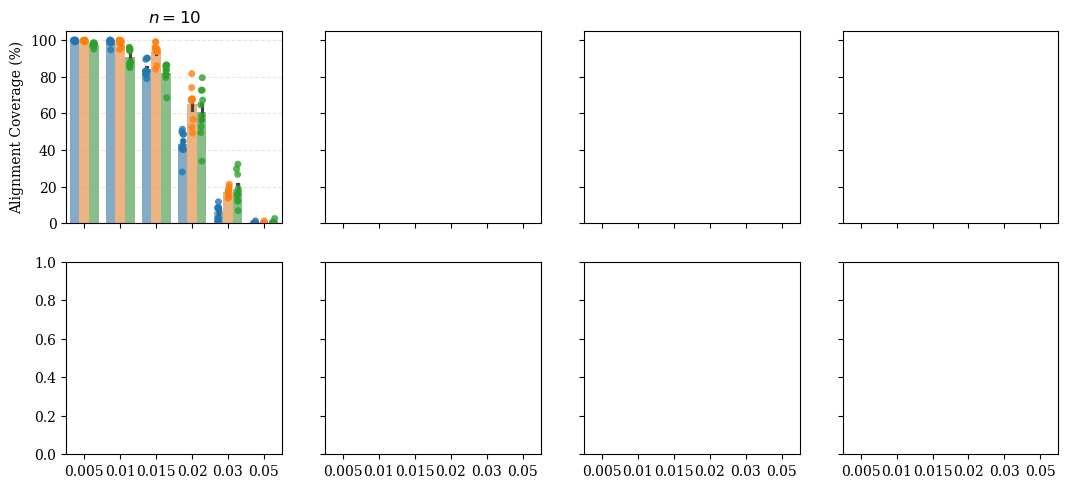

In [3]:
n_show = [10, 20, 50, 100]
alpha_x_show = [0.005, 0.01, 0.015, 0.02, 0.03, 0.05]
palette = "tab10"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


parsnp_plot = parsnp_df[
    parsnp_df['n'].isin(n_show) &
    parsnp_df['alpha'].isin(alpha_x_show)
].copy()

parsnp_metrics = [
    ('core_length', 'Alignment Coverage (%)'),
    ('SNP_f1', 'SNP F1 Score'),

]

fig, axes = plt.subplots(
    len(parsnp_metrics), len(n_show),
    figsize=(len(n_show) * 3.2, len(parsnp_metrics) * 2.5 + 0.5),
    sharey='row', sharex=True,
)

for col_idx, n_val in enumerate(n_show):
    df_sub = parsnp_plot[parsnp_plot['n'] == n_val]

    for row_idx, (metric, ylabel) in enumerate(parsnp_metrics):
        ax = axes[row_idx, col_idx]

        sns.barplot(
            data=df_sub, x='alpha', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
        )
        sns.stripplot(
            data=df_sub, x='alpha', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, legend=False, alpha=0.8, dodge=True,
        )

        if row_idx == 0:
            ax.set_title(f'$n={n_val}$', fontweight='bold')
        ax.set_xlabel(r'Mutation Rate ($\alpha$)' if row_idx == len(parsnp_metrics) - 1 else '')
        ax.set_ylabel(ylabel if col_idx == 0 else '')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if ax.get_legend():
            ax.get_legend().remove()

for row_idx in range(len(parsnp_metrics)):
    label = chr(ord('a') + row_idx)
    axes[row_idx, 0].text(-0.30, 1.03, f'({label})', transform=axes[row_idx, 0].transAxes,
                          fontsize=11, fontweight='bold', va='top', ha='right')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.08),
           ncol=4, frameon=False, title="Sequence Type")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('tp_fp_coverage_parsnp.png', dpi=300, bbox_inches='tight')
plt.savefig('tp_fp_coverage_parsnp.pdf', dpi=300, bbox_inches='tight')
plt.show()


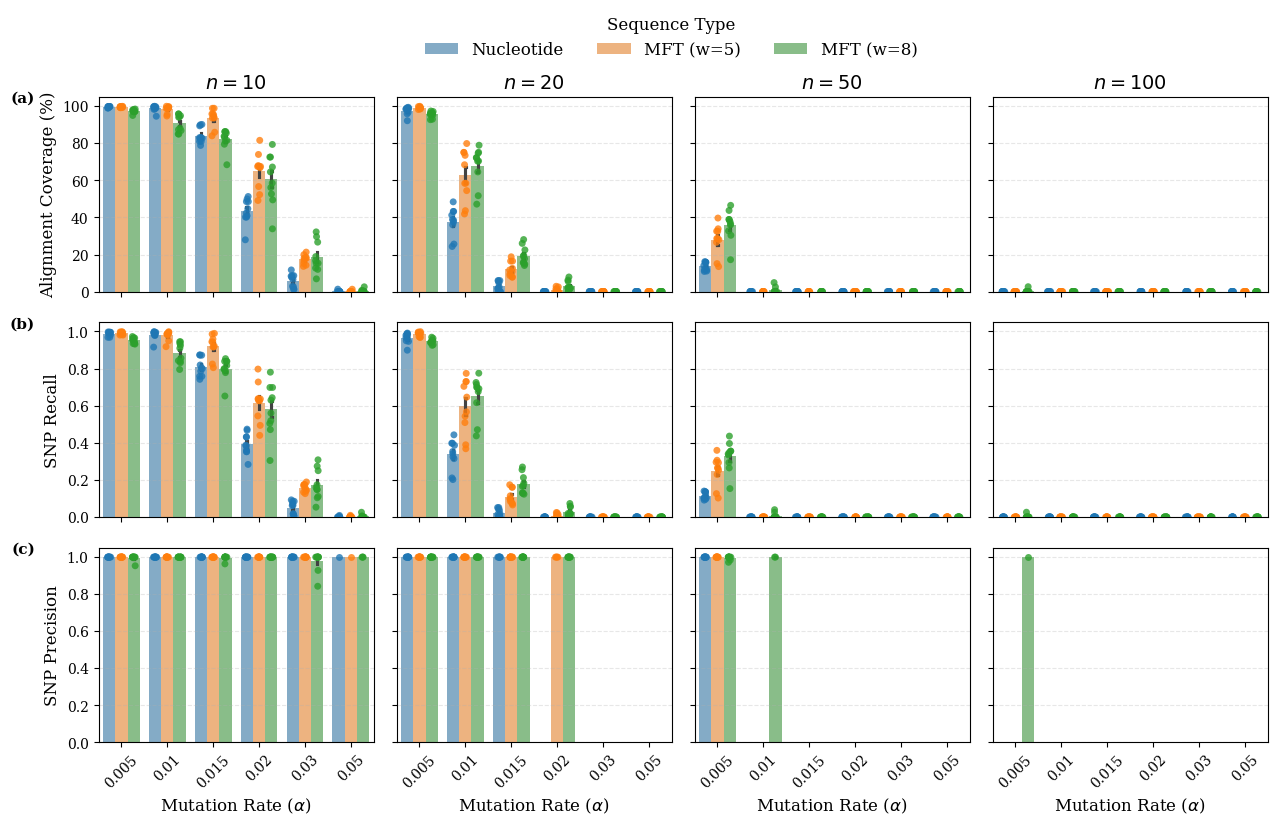

In [ ]:
parsnp_plot = parsnp_df[
    parsnp_df['n'].isin(n_show) &
    parsnp_df['alpha'].isin(alpha_x_show)
].copy()

parsnp_metrics = [
    ('core_length', 'Alignment Coverage (%)'),
    ('SNP_recall', 'SNP Recall'),
    ('SNP_precision', 'SNP Precision'),
]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axes = plt.subplots(
    len(parsnp_metrics), len(n_show),
    figsize=(len(n_show) * 3.2, len(parsnp_metrics) * 2.5 + 0.5),
    sharey='row', sharex=True,
)

for col_idx, n_val in enumerate(n_show):
    df_sub = parsnp_plot[parsnp_plot['n'] == n_val]

    for row_idx, (metric, ylabel) in enumerate(parsnp_metrics):
        ax = axes[row_idx, col_idx]

        sns.barplot(
            data=df_sub, x='alpha', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
        )
        sns.stripplot(
            data=df_sub, x='alpha', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, legend=False, alpha=0.8, dodge=True,
        )

        if row_idx == 0:
            ax.set_title(f'$n={n_val}$', fontweight='bold')
        ax.set_xlabel(r'Mutation Rate ($\alpha$)' if row_idx == len(parsnp_metrics) - 1 else '')
        ax.set_ylabel(ylabel if col_idx == 0 else '')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if ax.get_legend():
            ax.get_legend().remove()

for row_idx in range(len(parsnp_metrics)):
    label = chr(ord('a') + row_idx)
    axes[row_idx, 0].text(-0.23, 1.03, f'({label})', transform=axes[row_idx, 0].transAxes,
                          fontsize=11, fontweight='bold', va='top', ha='right')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.52, 1.04),
           ncol=4, frameon=False, title="Sequence Type")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('fig5.png', dpi=300, bbox_inches='tight')
plt.savefig('fig5.pdf', dpi=300, bbox_inches='tight')
plt.show()
